In [ ]:
!pip install ucimlrepo

## Getting LIbraries

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Getting data

In [ ]:
mines_data = fetch_ucirepo(id=763)

In [ ]:
mines_df = pd.DataFrame(mines_data.data.original)
mines_features = pd.DataFrame(mines_data.data.features)
mines_target = mines_df["M"]

In [ ]:
mines_df

,V,H,S,M
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
...,...,...,...,...
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5


## Dataset information

In [ ]:
print("Shape : ",mines_df.shape)
mines_df.info()

Shape :  (338, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V       338 non-null    float64
 1   H       338 non-null    float64
 2   S       338 non-null    float64
 3   M       338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [ ]:
mines_df.describe()

,V,H,S,M
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [ ]:
print("Unique targets :",mines_df["M"].unique())

Unique targets : [1 2 3 4 5]


In [ ]:
print("Unique Soil types (based on humidity level) :",mines_df["S"].unique())

Unique Soil types (based on humidity level) : [0.  0.6 0.2 0.8 0.4 1. ]


## Getting outliers

In [ ]:
def outlier_percentage_df(df):
    results = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        results[col] = round((mask.sum() / len(df)) * 100, 2)
    return pd.DataFrame.from_dict(results, orient='index', columns=['Outlier %']).sort_values(by="Outlier %",ascending=False)

outlier_percentage_df(mines_features)

,Outlier %
V,9.47
H,0.00
S,0.00


<Axes: >

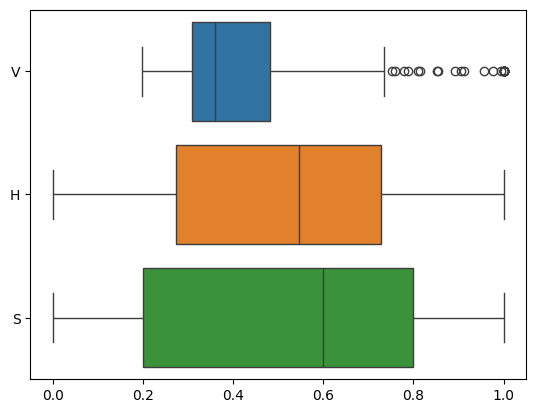

In [ ]:
sns.boxplot(mines_features,orient="h")

### Removing outliers (imputing as dataloss can be bad in this case)

In [ ]:
def impute_outliers_median(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_val = df[col].median()
    df_clean = df.copy()
    df_clean.loc[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound), col] = median_val
    return df_clean

mines_df = impute_outliers_median(mines_df,"V")
mines_features = mines_df[mines_features.columns]
mines_target = mines_df["M"]

In [ ]:
mines_features

,V,H,S
0,0.338157,0.000000,0.0
1,0.320241,0.181818,0.0
2,0.287009,0.272727,0.0
3,0.256284,0.454545,0.0
4,0.262840,0.545455,0.0
...,...,...,...
333,0.323262,0.909091,0.4
334,0.444108,0.181818,1.0
335,0.353474,0.454545,1.0
336,0.362537,0.727273,1.0


,Outlier %
V,5.03
H,0.00
S,0.00


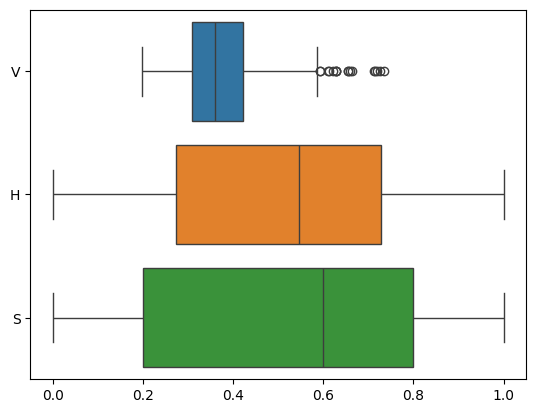

In [ ]:
sns.boxplot(mines_features,orient="h")
outlier_percentage_df(mines_features)

## Standardizing features

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
sc = StandardScaler()
mines_features.loc[:, ["V","H"]] = sc.fit_transform(mines_features[["V","H"]])

/tmp/ipykernel_211/2823842293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mines_features.loc[:, ["V","H"]] = sc.fit_transform(mines_features[["V","H"]])


In [ ]:
mines_features

,V,H,S
0,-0.366583,-1.665222,0.0
1,-0.541184,-1.070248,0.0
2,-0.865064,-0.772762,0.0
3,-1.164506,-0.177788,0.0
4,-1.100612,0.119699,0.0
...,...,...,...
333,-0.511740,1.309646,0.4
334,0.666004,-1.070248,1.0
335,-0.217304,-0.177788,1.0
336,-0.128973,0.714672,1.0


In [ ]:
mines_df = pd.concat([mines_features,mines_target],axis=1)

In [ ]:
mines_df

,V,H,S,M
0,-0.366583,-1.665222,0.0,1
1,-0.541184,-1.070248,0.0,1
2,-0.865064,-0.772762,0.0,1
3,-1.164506,-0.177788,0.0,1
4,-1.100612,0.119699,0.0,1
...,...,...,...,...
333,-0.511740,1.309646,0.4,5
334,0.666004,-1.070248,1.0,5
335,-0.217304,-0.177788,1.0,5
336,-0.128973,0.714672,1.0,5


## Applying Classifiers

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix,roc_curve, auc
from sklearn.preprocessing import label_binarize

### Decision Trees Classifier (10-fold cross validation)

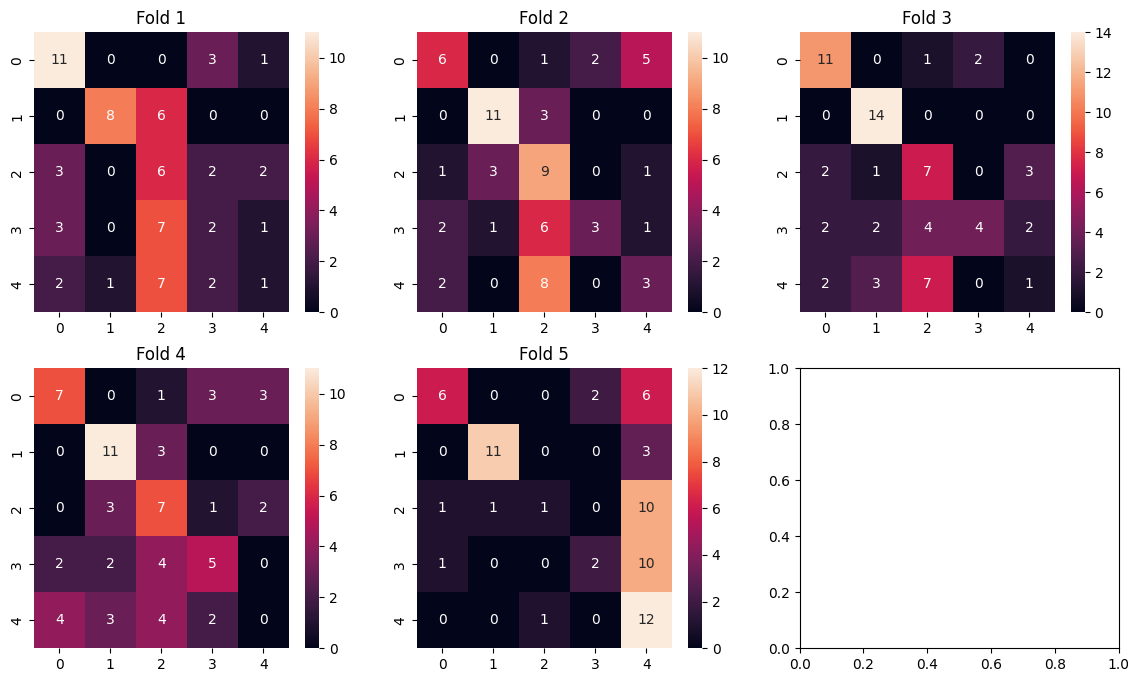

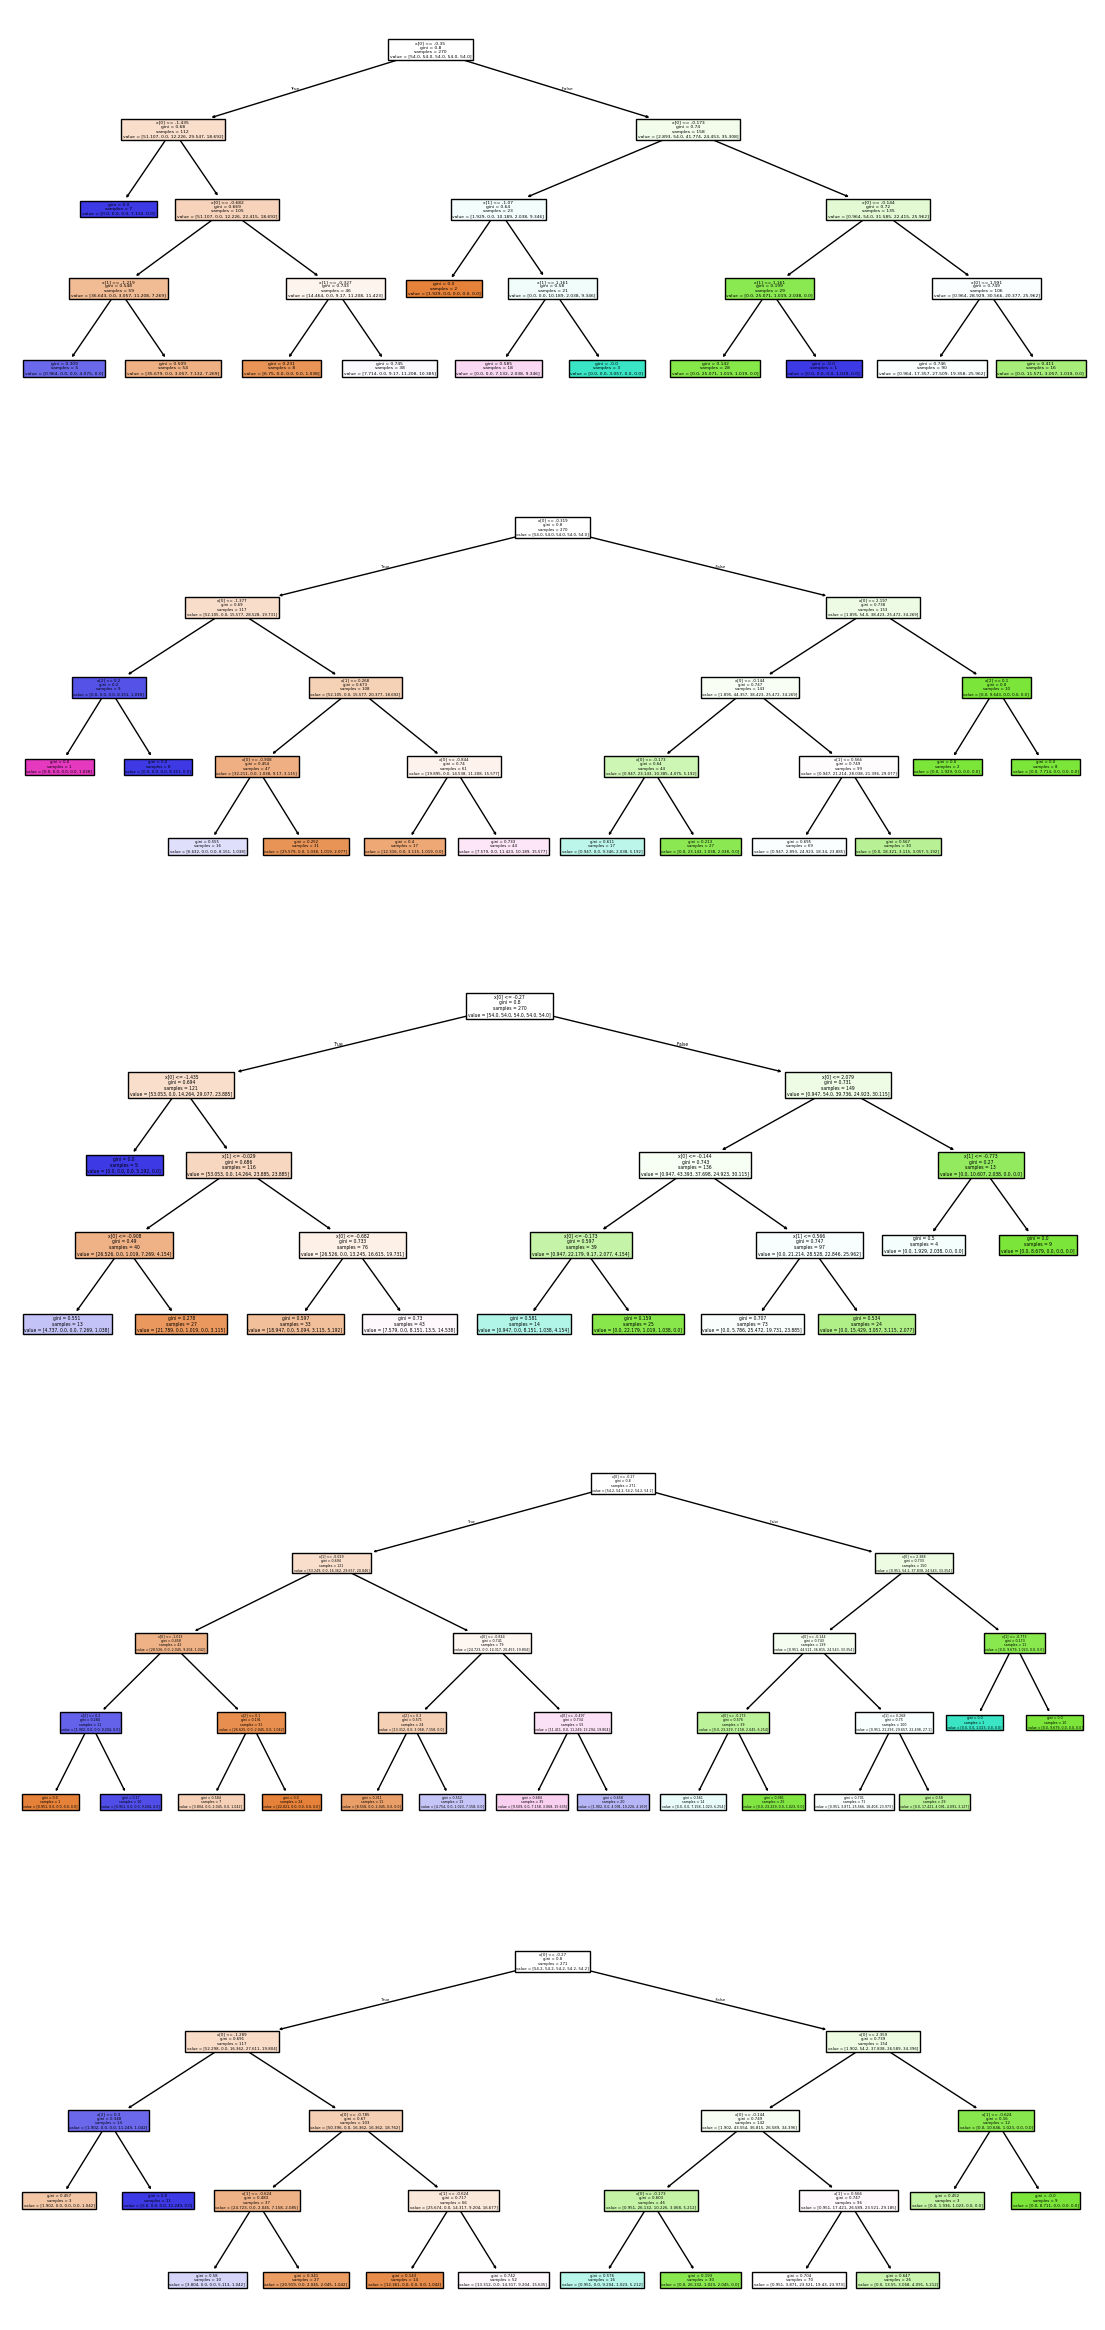

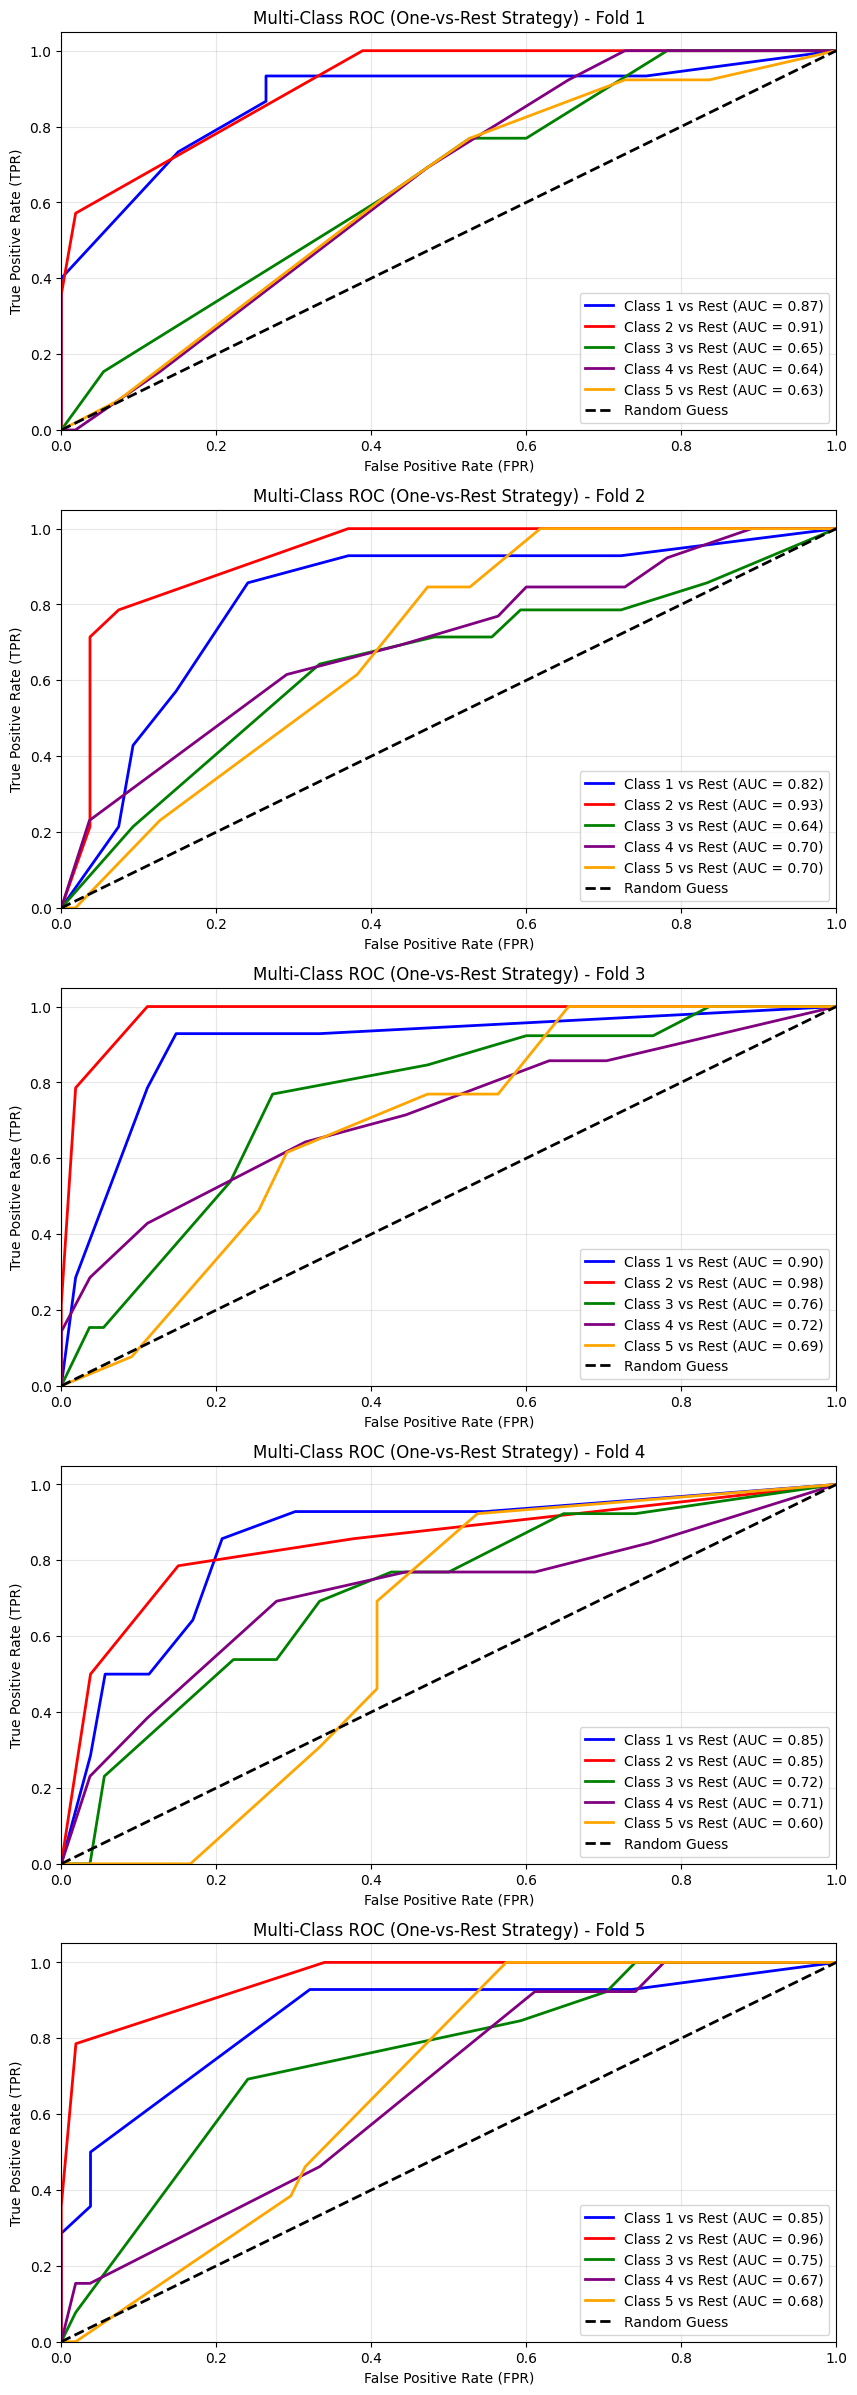


 Summary across folds:
Fold     Accuracy     F1           Precision    Recall      
----------------------------------------------------
1        0.4118       0.4008       0.4356       0.4118      
2        0.4706       0.4590       0.5040       0.4706      
3        0.5441       0.5018       0.5169       0.5441      
4        0.4478       0.4134       0.3932       0.4478      
5        0.4776       0.4485       0.5991       0.4776      
----------------------------------------------------
Mean    0.4704      0.4447      0.4897      0.4704      
Std     0.0434      0.0357      0.0709      0.0434      


In [ ]:
dt_metric = []

fig1,ax1 = plt.subplots(2,3,figsize=(14,8))
fig2,ax2 = plt.subplots(5,1,figsize=(14,30))
fig3,ax3 = plt.subplots(5,1,figsize=(10,30))
for i,(train_index, test_index) in enumerate(StratifiedKFold(n_splits=5,shuffle=True,random_state=1).split(mines_features,mines_target)):
    dt_model = DecisionTreeClassifier(max_depth=4, min_samples_split=5, class_weight='balanced', random_state=42)

    mines_X_train,mines_X_test = mines_features.iloc[train_index],mines_features.iloc[test_index]
    mines_y_train,mines_y_test = mines_target.iloc[train_index],mines_target.iloc[test_index]

    dt_model.fit(mines_X_train,mines_y_train)
    mines_y_pred = dt_model.predict(mines_X_test)
    ax1[i//3,i%3].set_title(f"Fold {i+1}")
    sns.heatmap(confusion_matrix(mines_y_test,mines_y_pred,labels=sorted(mines_y_test.unique())),annot=True,ax=ax1[i//3,i%3])

    y_score = dt_model.predict_proba(mines_X_test)
    colors = ['blue', 'red', 'green', 'purple', 'orange']

    mines_y_test_binarized = label_binarize(mines_y_test, classes=mines_target.unique())
    n_classes = mines_y_test_binarized.shape[1]

    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(mines_y_test_binarized[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)

        ax3[i].plot(fpr, tpr, color=colors[j], lw=2,
                label=f'Class {mines_target.unique()[j]} vs Rest (AUC = {roc_auc:.2f})')

    ax3[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    ax3[i].set_xlim([0.0, 1.0])
    ax3[i].set_ylim([0.0, 1.05])
    ax3[i].set_xlabel('False Positive Rate (FPR)')
    ax3[i].set_ylabel('True Positive Rate (TPR)')
    ax3[i].set_title(f'Multi-Class ROC (One-vs-Rest Strategy) - Fold {i+1}')
    ax3[i].legend(loc="lower right")
    ax3[i].grid(alpha=0.3)

    ax2[i].set_title(f"Fold {i+1}")
    plot_tree(dt_model,filled=True,ax=ax2[i])

    fold_results = {
        "fold":      i + 1,
        "accuracy":  accuracy_score(mines_y_test, mines_y_pred),
        "f1":        f1_score(mines_y_test, mines_y_pred, average='weighted'),
        "precision": precision_score(mines_y_test, mines_y_pred, average='weighted'),
        "recall":    recall_score(mines_y_test, mines_y_pred, average='weighted'),
    }
    dt_metric.append(fold_results)

plt.show()
print("\n Summary across folds:")
print(f"{'Fold':<8} {'Accuracy':<12} {'F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for r in dt_metric:
    print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {r['f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")

print("-" * 52)
metrics = ['accuracy', 'f1', 'precision', 'recall']
print(f"{'Mean':<8}", end="")
for m in metrics:
    print(f"{np.mean([r[m] for r in dt_metric]):<12.4f}", end="")
print()
print(f"{'Std':<8}", end="")
for m in metrics:
    print(f"{np.std([r[m] for r in dt_metric]):<12.4f}", end="")
print()

### Naive Bayes Classifier (10-fold cross validation)

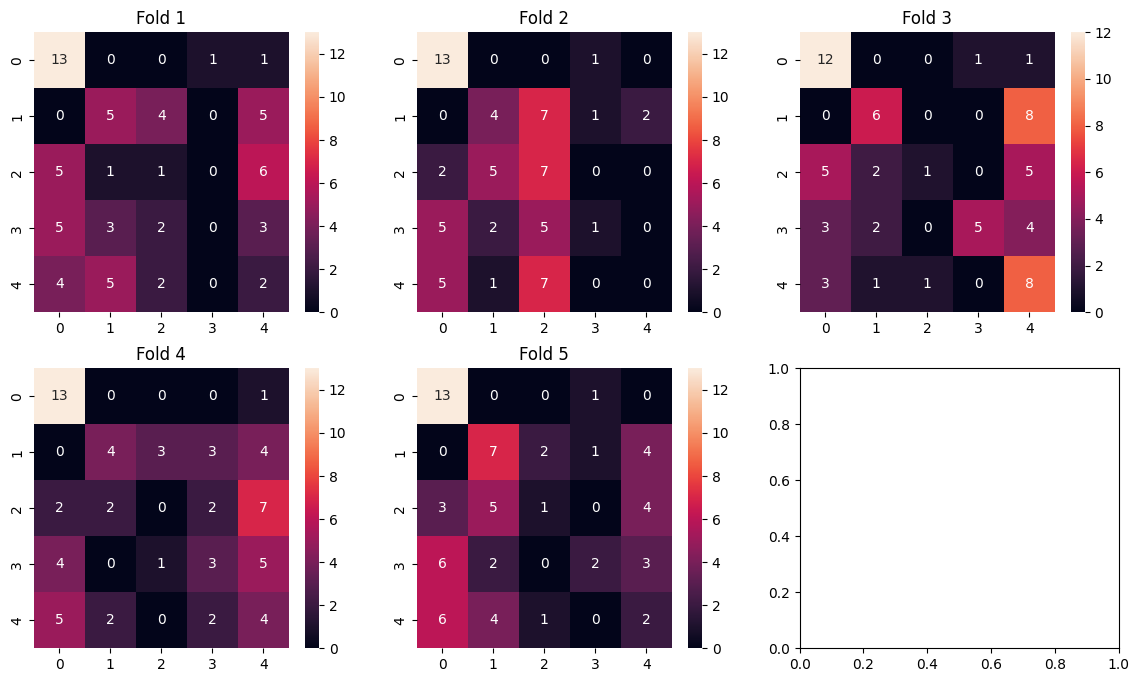

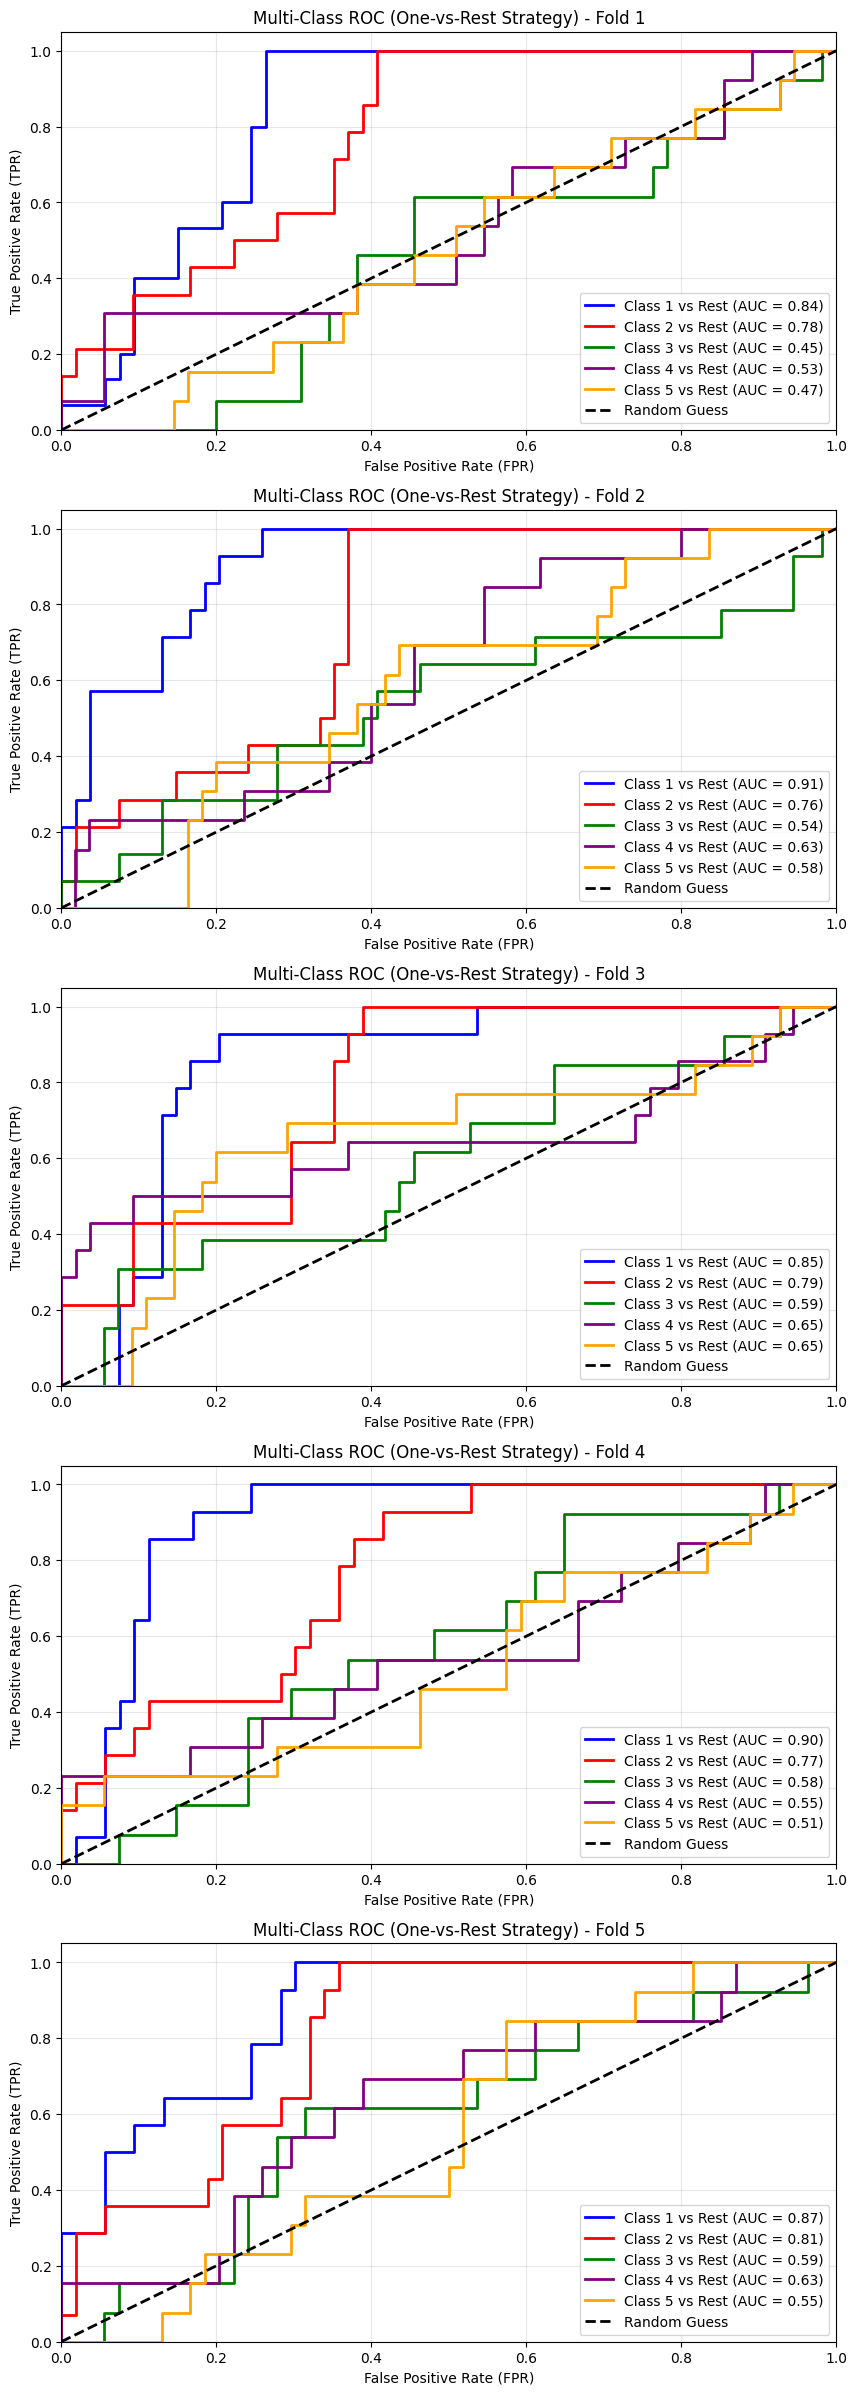


 Summary across folds:
Fold     Accuracy     F1           Precision    Recall      
----------------------------------------------------
1        0.3088       0.2530       0.2235       0.3088      
2        0.3676       0.2966       0.2948       0.3676      
3        0.4706       0.4392       0.5457       0.4706      
4        0.3582       0.3152       0.3128       0.3582      
5        0.3731       0.3191       0.3536       0.3731      
----------------------------------------------------
Mean    0.3757      0.3246      0.3461      0.3757      
Std     0.0526      0.0619      0.1083      0.0526      


In [ ]:
nb_metric = []

fig,ax = plt.subplots(2,3,figsize=(14,8))
fig3,ax3 = plt.subplots(5,1,figsize=(10,30))
for i,(train_index, test_index) in enumerate(StratifiedKFold(n_splits=5,shuffle=True,random_state=1).split(mines_features,mines_target)):
    nb_model = GaussianNB()

    mines_X_train,mines_X_test = mines_features.iloc[train_index],mines_features.iloc[test_index]
    mines_y_train,mines_y_test = mines_target.iloc[train_index],mines_target.iloc[test_index]

    nb_model.fit(mines_X_train,mines_y_train)
    mines_y_pred = nb_model.predict(mines_X_test)
    ax[i//3,i%3].set_title(f"Fold {i+1}")
    sns.heatmap(confusion_matrix(mines_y_test,mines_y_pred,labels=sorted(mines_y_test.unique())),annot=True,ax=ax[i//3,i%3])

    y_score = nb_model.predict_proba(mines_X_test)
    colors = ['blue', 'red', 'green', 'purple', 'orange']

    mines_y_test_binarized = label_binarize(mines_y_test, classes=mines_target.unique())
    n_classes = mines_y_test_binarized.shape[1]

    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(mines_y_test_binarized[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)

        ax3[i].plot(fpr, tpr, color=colors[j], lw=2,
                label=f'Class {mines_target.unique()[j]} vs Rest (AUC = {roc_auc:.2f})')

    ax3[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    ax3[i].set_xlim([0.0, 1.0])
    ax3[i].set_ylim([0.0, 1.05])
    ax3[i].set_xlabel('False Positive Rate (FPR)')
    ax3[i].set_ylabel('True Positive Rate (TPR)')
    ax3[i].set_title(f'Multi-Class ROC (One-vs-Rest Strategy) - Fold {i+1}')
    ax3[i].legend(loc="lower right")
    ax3[i].grid(alpha=0.3)

    fold_results = {
        "fold":      i + 1,
        "accuracy":  accuracy_score(mines_y_test, mines_y_pred),
        "f1":        f1_score(mines_y_test, mines_y_pred, average='weighted'),
        "precision": precision_score(mines_y_test, mines_y_pred, average='weighted'),
        "recall":    recall_score(mines_y_test, mines_y_pred, average='weighted'),
    }
    nb_metric.append(fold_results)
plt.show()
print("\n Summary across folds:")
print(f"{'Fold':<8} {'Accuracy':<12} {'F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for r in nb_metric:
    print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {r['f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")

print("-" * 52)
metrics = ['accuracy', 'f1', 'precision', 'recall']
print(f"{'Mean':<8}", end="")
for m in metrics:
    print(f"{np.mean([r[m] for r in nb_metric]):<12.4f}", end="")
print()
print(f"{'Std':<8}", end="")
for m in metrics:
    print(f"{np.std([r[m] for r in nb_metric]):<12.4f}", end="")
print()


### K-Nearest Neighbours Classifier (10-fold cross validation)

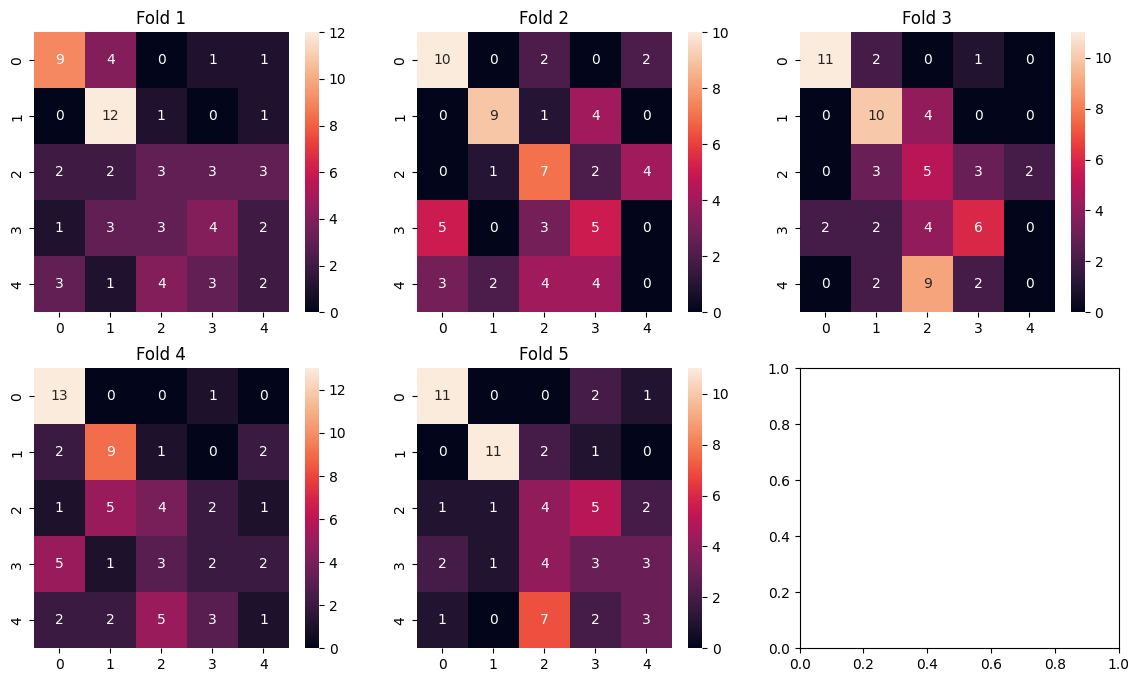

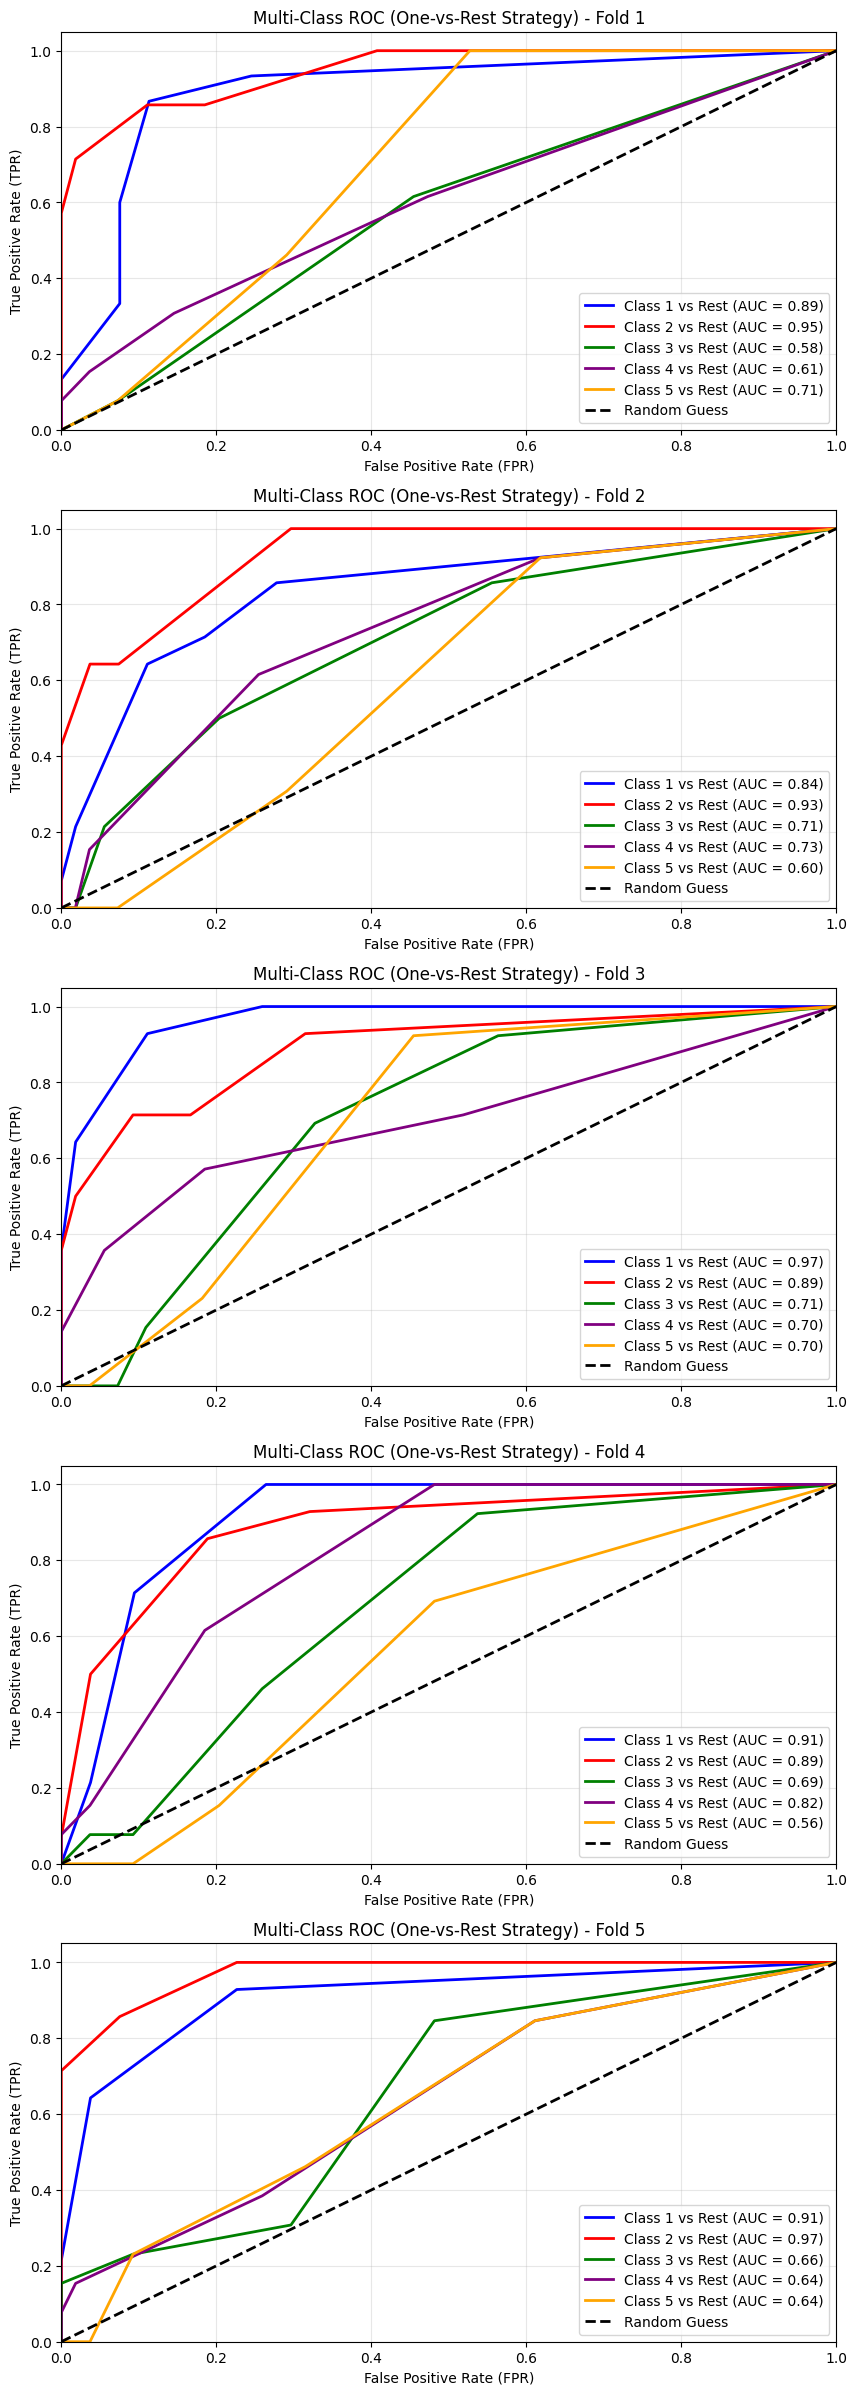


 Summary across folds:
Fold     Accuracy     F1           Precision    Recall      
----------------------------------------------------
1        0.4412       0.4159       0.4088       0.4412      
2        0.4559       0.4325       0.4173       0.4559      
3        0.4706       0.4422       0.4290       0.4706      
4        0.4328       0.3852       0.3693       0.4328      
5        0.4776       0.4782       0.4851       0.4776      
----------------------------------------------------
Mean    0.4556      0.4308      0.4219      0.4556      
Std     0.0169      0.0306      0.0375      0.0169      


In [ ]:
knn_metric = []

fig,ax = plt.subplots(2,3,figsize=(14,8))
fig3,ax3 = plt.subplots(5,1,figsize=(10,30))
for i,(train_index, test_index) in enumerate(StratifiedKFold(n_splits=5,shuffle=True,random_state=1).split(mines_features,mines_target)):
    knn_model = KNeighborsClassifier()

    mines_X_train,mines_X_test = mines_features.iloc[train_index],mines_features.iloc[test_index]
    mines_y_train,mines_y_test = mines_target.iloc[train_index],mines_target.iloc[test_index]

    knn_model.fit(mines_X_train,mines_y_train)
    mines_y_pred = knn_model.predict(mines_X_test)
    ax[i//3,i%3].set_title(f"Fold {i+1}")
    sns.heatmap(confusion_matrix(mines_y_test,mines_y_pred,labels=sorted(mines_y_test.unique())),annot=True,ax=ax[i//3,i%3])

    y_score = knn_model.predict_proba(mines_X_test)
    colors = ['blue', 'red', 'green', 'purple', 'orange']

    mines_y_test_binarized = label_binarize(mines_y_test, classes=mines_target.unique())
    n_classes = mines_y_test_binarized.shape[1]

    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(mines_y_test_binarized[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)

        ax3[i].plot(fpr, tpr, color=colors[j], lw=2,
                label=f'Class {mines_target.unique()[j]} vs Rest (AUC = {roc_auc:.2f})')

    ax3[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    ax3[i].set_xlim([0.0, 1.0])
    ax3[i].set_ylim([0.0, 1.05])
    ax3[i].set_xlabel('False Positive Rate (FPR)')
    ax3[i].set_ylabel('True Positive Rate (TPR)')
    ax3[i].set_title(f'Multi-Class ROC (One-vs-Rest Strategy) - Fold {i+1}')
    ax3[i].legend(loc="lower right")
    ax3[i].grid(alpha=0.3)
    fold_results = {
        "fold":      i + 1,
        "accuracy":  accuracy_score(mines_y_test, mines_y_pred),
        "f1":        f1_score(mines_y_test, mines_y_pred, average='weighted',zero_division=1.0),
        "precision": precision_score(mines_y_test, mines_y_pred, average='weighted',zero_division=1.0),
        "recall":    recall_score(mines_y_test, mines_y_pred, average='weighted',zero_division=1.0),
    }
    knn_metric.append(fold_results)
plt.show()
print("\n Summary across folds:")
print(f"{'Fold':<8} {'Accuracy':<12} {'F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for r in knn_metric:
    print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {r['f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")

print("-" * 52)
metrics = ['accuracy', 'f1', 'precision', 'recall']
print(f"{'Mean':<8}", end="")
for m in metrics:
    print(f"{np.mean([r[m] for r in knn_metric]):<12.4f}", end="")
print()
print(f"{'Std':<8}", end="")
for m in metrics:
    print(f"{np.std([r[m] for r in knn_metric]):<12.4f}", end="")
print()
